# Tarea N°8 — Support Vector Machines (SVM)

**Dataset:** `developer_stress.csv` 

**Nombres:** Matias Machuca - Luna Leon



+


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, accuracy_score)

sns.set(style="whitegrid")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. Carga y exploración inicial de los datos

In [2]:
# Ruta robusta al CSV (ajustar si fuese necesario)
candidatos = [
    "developer_stress.csv",
    r"../PCA_Analisis_Factorial/data/developer_stress.csv",
    r"D:/Proyectos/Universidad/Mineria/PCA_Analisis_Factorial/data/developer_stress.csv",
]
ruta = next((p for p in candidatos if __import__('os').path.exists(p)), candidatos[-1])
df = pd.read_csv(ruta)
print("Dimensiones:", df.shape)
df.head()

Dimensiones: (500, 11)


,Hours_Worked,Sleep_Hours,Bugs,Deadline_Days,Coffee_Cups,Meetings,Interruptions,Experience_Years,Code_Complexity,Remote_Work,Stress_Level
0,10,8,25,53,4,9,2,Senior,Medium,Yes,58.521033
1,7,8,33,33,2,6,9,Junior,Medium,Yes,47.461651
2,14,8,44,54,10,12,2,Junior,Low,No,59.211580
3,11,6,5,46,0,13,9,Mid,Low,Yes,100.000000
4,8,7,36,23,9,3,2,Junior,Medium,Yes,28.784957


In [3]:
print(df.dtypes)
print("\nValores nulos por columna:")
print(df.isna().sum())

Hours_Worked          int64
Sleep_Hours           int64
Bugs                  int64
Deadline_Days         int64
Coffee_Cups           int64
Meetings              int64
Interruptions         int64
Experience_Years     object
Code_Complexity      object
Remote_Work          object
Stress_Level        float64
dtype: object

Valores nulos por columna:
Hours_Worked        0
Sleep_Hours         0
Bugs                0
Deadline_Days       0
Coffee_Cups         0
Meetings            0
Interruptions       0
Experience_Years    0
Code_Complexity     0
Remote_Work         0
Stress_Level        0
dtype: int64


In [4]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Hours_Worked,500.0,NaN,NaN,NaN,9.504,3.543317,4.0,6.0,10.0,13.0,15.0
Sleep_Hours,500.0,NaN,NaN,NaN,5.436,1.706378,3.0,4.0,5.0,7.0,8.0
Bugs,500.0,NaN,NaN,NaN,25.15,14.909866,0.0,11.0,26.0,37.0,50.0
Deadline_Days,500.0,NaN,NaN,NaN,30.676,17.284691,0.0,16.0,31.0,45.0,60.0
Coffee_Cups,500.0,NaN,NaN,NaN,4.922,3.155286,0.0,2.0,5.0,8.0,10.0
Meetings,500.0,NaN,NaN,NaN,10.164,6.227573,0.0,5.0,10.0,16.0,20.0
Interruptions,500.0,NaN,NaN,NaN,4.968,3.074717,0.0,2.0,5.0,8.0,10.0
Experience_Years,500,3,Senior,187,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Code_Complexity,500,3,Medium,206,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Remote_Work,500,2,No,255,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Construcción de la variable objetivo (clasificación)

El estrés se discretiza en 3 niveles:

| Categoría | Rango de `Stress_Level` |
|-----------|-------------------------|
| **Bajo**  | < 50                    |
| **Medio** | 50 – 80                 |
| **Alto**  | > 80                    |


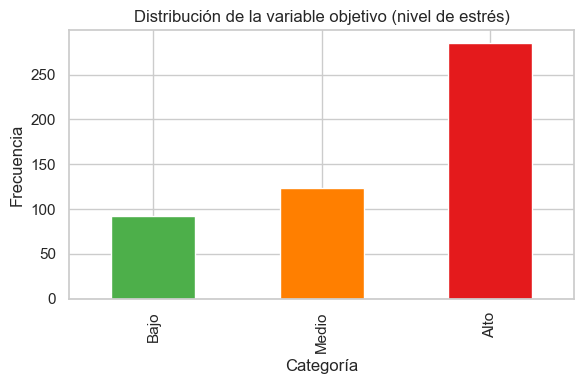

Stress_Cat
Alto     285
Medio    123
Bajo      92
Name: count, dtype: int64

In [5]:
df['Stress_Cat'] = pd.cut(df['Stress_Level'],
                          bins=[-np.inf, 50, 80, np.inf],
                          labels=['Bajo', 'Medio', 'Alto'])

ax = df['Stress_Cat'].value_counts().reindex(['Bajo','Medio','Alto']).plot(
        kind='bar', color=['#4daf4a','#ff7f00','#e41a1c'], figsize=(6,4))
ax.set_title('Distribución de la variable objetivo (nivel de estrés)')
ax.set_xlabel('Categoría'); ax.set_ylabel('Frecuencia')
plt.tight_layout(); plt.show()
df['Stress_Cat'].value_counts()

## 3. Preparación de variables (features) y preprocesamiento

- **Numéricas** → escaladas con `StandardScaler` (SVM es sensible a la escala).
- **Categóricas** (`Experience_Years`, `Code_Complexity`, `Remote_Work`) → codificadas con `OneHotEncoder`.

Se usa un `ColumnTransformer` dentro de un `Pipeline` para evitar fuga de datos
(*data leakage*): el escalado se ajusta solo con el conjunto de entrenamiento dentro de cada *fold*.


In [6]:
X = df.drop(columns=['Stress_Level', 'Stress_Cat'])
y = df['Stress_Cat']

num_cols = X.select_dtypes(include=np.number).columns.tolist()
cat_cols = X.select_dtypes(exclude=np.number).columns.tolist()
print("Numéricas:", num_cols)
print("Categóricas:", cat_cols)

preprocesador = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
])

Numéricas: ['Hours_Worked', 'Sleep_Hours', 'Bugs', 'Deadline_Days', 'Coffee_Cups', 'Meetings', 'Interruptions']
Categóricas: ['Experience_Years', 'Code_Complexity', 'Remote_Work']


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE)
print("Entrenamiento:", X_train.shape, " | Prueba:", X_test.shape)

Entrenamiento: (375, 10)  | Prueba: (125, 10)


## 4. SVM con 3 kernels + Cross Validation

Definimos un *pipeline* (preprocesamiento + SVM) por cada kernel y validamos cada uno
con **validación cruzada estratificada de 5 folds** sobre el conjunto de entrenamiento.

> **Manejo del desbalance:** las clases están desbalanceadas (Alto≈57%, Medio≈25%, Bajo≈18%,
> razón ≈ 3:1). Se usa `class_weight='balanced'`, que pondera el costo de cada error de forma
> inversamente proporcional a la frecuencia de su clase, de modo que los errores en las clases
> minoritarias (`Medio`, `Bajo`) pesen más. Esto suele mejorar el *recall/F1* de esas clases,
> aunque el *accuracy* global puede bajar levemente.


In [8]:
kernels = {
    'Lineal':      SVC(kernel='linear',  C=1.0,                       class_weight='balanced', random_state=RANDOM_STATE),
    'RBF':         SVC(kernel='rbf',     C=1.0, gamma='scale',        class_weight='balanced', random_state=RANDOM_STATE),
    'Polinomial':  SVC(kernel='poly',    C=1.0, degree=3, gamma='scale', class_weight='balanced', random_state=RANDOM_STATE),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
resultados = []

for nombre, modelo in kernels.items():
    pipe = Pipeline([('prep', preprocesador), ('svm', modelo)])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='accuracy')
    resultados.append({
        'Kernel': nombre,
        'CV Accuracy media': scores.mean(),
        'CV Std': scores.std(),
        'Scores por fold': np.round(scores, 4),
    })
    print(f"{nombre:11s} -> accuracy CV = {scores.mean():.4f} ± {scores.std():.4f}")

cv_df = pd.DataFrame(resultados)
cv_df

Lineal      -> accuracy CV = 0.7840 ± 0.0309
RBF         -> accuracy CV = 0.8053 ± 0.0410
Polinomial  -> accuracy CV = 0.7600 ± 0.0470


,Kernel,CV Accuracy media,CV Std,Scores por fold
0,Lineal,0.784000,0.030869,"[0.8133, 0.7467, 0.76, 0.7733, 0.8267]"
1,RBF,0.805333,0.040966,"[0.8267, 0.76, 0.8133, 0.76, 0.8667]"
2,Polinomial,0.760000,0.046952,"[0.8267, 0.68, 0.7733, 0.76, 0.76]"


### 4.1 Comparación visual de la validación cruzada

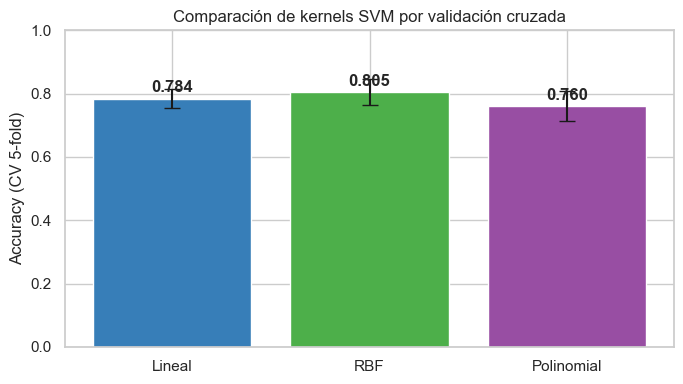

In [9]:
fig, ax = plt.subplots(figsize=(7,4))
ax.bar(cv_df['Kernel'], cv_df['CV Accuracy media'],
       yerr=cv_df['CV Std'], capsize=6,
       color=['#377eb8','#4daf4a','#984ea3'])
ax.set_ylabel('Accuracy (CV 5-fold)')
ax.set_title('Comparación de kernels SVM por validación cruzada')
ax.set_ylim(0, 1)
for i, v in enumerate(cv_df['CV Accuracy media']):
    ax.text(i, v + 0.02, f"{v:.3f}", ha='center', fontweight='bold')
plt.tight_layout(); plt.show()

## 5. Evaluación final en el conjunto de prueba

Entrenamos cada kernel con todo el set de entrenamiento y medimos su desempeño
en el set de prueba (no visto), con matriz de confusión y reporte de clasificación.


===== Kernel Lineal =====
              precision    recall  f1-score   support

        Alto       0.93      0.89      0.91        71
        Bajo       0.85      0.74      0.79        23
       Medio       0.65      0.77      0.71        31

    accuracy                           0.83       125
   macro avg       0.81      0.80      0.80       125
weighted avg       0.84      0.83      0.84       125

===== Kernel RBF =====
              precision    recall  f1-score   support

        Alto       0.95      0.89      0.92        71
        Bajo       0.85      0.74      0.79        23
       Medio       0.64      0.81      0.71        31

    accuracy                           0.84       125
   macro avg       0.82      0.81      0.81       125
weighted avg       0.86      0.84      0.85       125

===== Kernel Polinomial =====
              precision    recall  f1-score   support

        Alto       0.94      0.89      0.91        71
        Bajo       0.85      0.48      0.61       

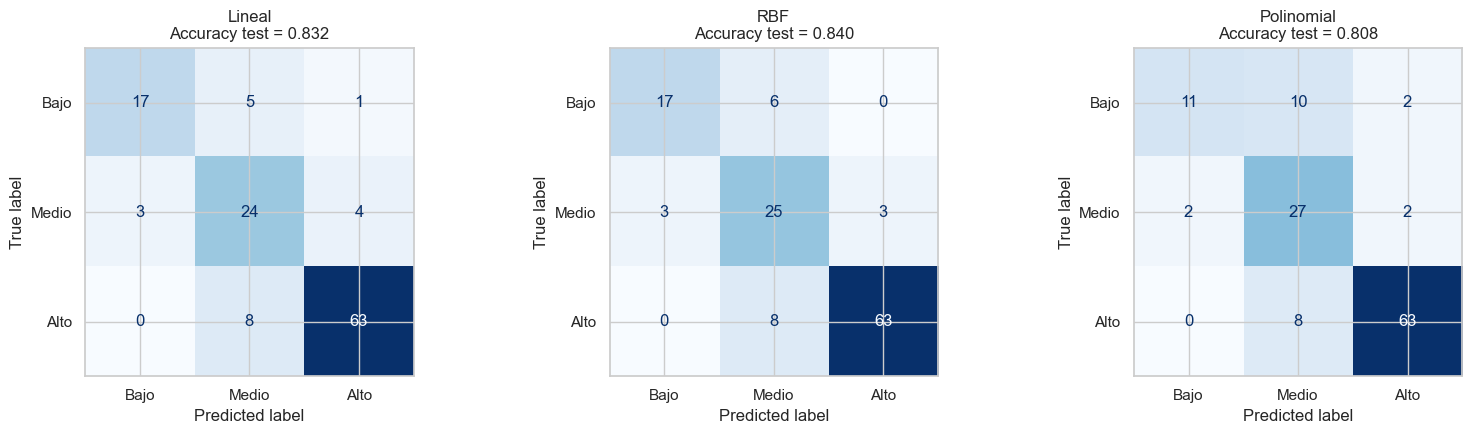

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
test_scores = {}

for ax, (nombre, modelo) in zip(axes, kernels.items()):
    pipe = Pipeline([('prep', preprocesador), ('svm', modelo)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    test_scores[nombre] = acc

    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred, labels=['Bajo','Medio','Alto'],
        cmap='Blues', ax=ax, colorbar=False)
    ax.set_title(f"{nombre}\nAccuracy test = {acc:.3f}")

    print(f"===== Kernel {nombre} =====")
    print(classification_report(y_test, y_pred, zero_division=0))

plt.tight_layout(); plt.show()

### 5.1 Resumen comparativo final

In [11]:
resumen = cv_df[['Kernel','CV Accuracy media','CV Std']].copy()
resumen['Accuracy test'] = resumen['Kernel'].map(test_scores)
resumen = resumen.sort_values('CV Accuracy media', ascending=False).reset_index(drop=True)
resumen.style.format({'CV Accuracy media':'{:.4f}','CV Std':'{:.4f}','Accuracy test':'{:.4f}'})

,Kernel,CV Accuracy media,CV Std,Accuracy test
0,RBF,0.8053,0.0410,0.8400
1,Lineal,0.7840,0.0309,0.8320
2,Polinomial,0.7600,0.0470,0.8080


## 6. Conclusiones

- Se aplicaron **tres kernels de SVM** (lineal, RBF y polinomial) sobre los datos de estrés de
  desarrolladores, prediciendo el nivel de estrés discretizado en `Bajo` / `Medio` / `Alto`.
- Cada modelo fue validado con **Cross Validation estratificada de 5 folds**, lo que entrega una
  estimación más robusta del desempeño que una única partición train/test.
- La tabla y los gráficos comparan los kernels tanto en validación cruzada como en el conjunto de
  prueba. El kernel con mayor *accuracy* media en CV es el recomendado para estos datos.
- **Notas técnicas:** las variables se escalaron (`StandardScaler`) porque SVM depende de las
  distancias; las categóricas se codificaron con *one-hot*; y todo el preprocesamiento se encapsuló
  en un `Pipeline` para evitar fuga de información durante la validación cruzada.
